<a href="https://colab.research.google.com/github/KarlaRL666/DataAnalysisPython/blob/main/LimpiezaYNormalizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Paso 1: Importar librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# ---------------------------------------
# CREACIÓN DE DATOS
# ---------------------------------------
# Paso 2: Simular un dataset con lecturas de consumo energético
# Incluimos valores faltantes y atípicos para aplicar limpieza
data = {
 "Tiempo": pd.date_range("2026-06-03 08:00", periods=12, freq="H"),
 "Consumo_kWh": [1.2, 2.5, None, 3.0, 50.0, 2.8, 2.2, None, 3.1, 2.9, 2.7, 2.6],
 "Temperatura": [22, 23, 22, None, 21, 22, 23, 24, None, 22, 23, 22],
 "Habitacion":
["Sala","Cocina","Sala","Recamara","Sala","Cocina","Recamara","Sala","Cocina","Recamara","Sala","Cocina"]
}
df = pd.DataFrame(data)
print("Datos originales con problemas:")
print(df)

Datos originales con problemas:
                Tiempo  Consumo_kWh  Temperatura Habitacion
0  2026-06-03 08:00:00          1.2         22.0       Sala
1  2026-06-03 09:00:00          2.5         23.0     Cocina
2  2026-06-03 10:00:00          NaN         22.0       Sala
3  2026-06-03 11:00:00          3.0          NaN   Recamara
4  2026-06-03 12:00:00         50.0         21.0       Sala
5  2026-06-03 13:00:00          2.8         22.0     Cocina
6  2026-06-03 14:00:00          2.2         23.0   Recamara
7  2026-06-03 15:00:00          NaN         24.0       Sala
8  2026-06-03 16:00:00          3.1          NaN     Cocina
9  2026-06-03 17:00:00          2.9         22.0   Recamara
10 2026-06-03 18:00:00          2.7         23.0       Sala
11 2026-06-03 19:00:00          2.6         22.0     Cocina


/tmp/ipykernel_3350/1909857427.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "Tiempo": pd.date_range("2026-06-03 08:00", periods=12, freq="H"),


In [ ]:
# ---------------------------------------
# LIMPIEZA DE DATOS
# ---------------------------------------
# Paso 3: Manejo de valores faltantes
# Rellenamos valores faltantes con la media de la columna
df["Consumo_kWh"].fillna(df["Consumo_kWh"].mean(), inplace=True)
df["Temperatura"].fillna(df["Temperatura"].mean(), inplace=True)
print(df)

                Tiempo  Consumo_kWh  Temperatura Habitacion
0  2026-06-03 08:00:00          1.2         22.0       Sala
1  2026-06-03 09:00:00          2.5         23.0     Cocina
2  2026-06-03 10:00:00          7.3         22.0       Sala
3  2026-06-03 11:00:00          3.0         22.4   Recamara
4  2026-06-03 12:00:00         50.0         21.0       Sala
5  2026-06-03 13:00:00          2.8         22.0     Cocina
6  2026-06-03 14:00:00          2.2         23.0   Recamara
7  2026-06-03 15:00:00          7.3         24.0       Sala
8  2026-06-03 16:00:00          3.1         22.4     Cocina
9  2026-06-03 17:00:00          2.9         22.0   Recamara
10 2026-06-03 18:00:00          2.7         23.0       Sala
11 2026-06-03 19:00:00          2.6         22.0     Cocina


/tmp/ipykernel_3350/3854709361.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Consumo_kWh"].fillna(df["Consumo_kWh"].mean(), inplace=True)
/tmp/ipykernel_3350/3854709361.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [ ]:
# Paso 4: Detección y corrección de valores atípicos
# Consideramos que un consumo > 10 kWh en una hora es anómalo
df.loc[df["Consumo_kWh"] > 10, "Consumo_kWh"] = df["Consumo_kWh"].mean()
print(df)

                Tiempo  Consumo_kWh  Temperatura Habitacion
0  2026-06-03 08:00:00          1.2         22.0       Sala
1  2026-06-03 09:00:00          2.5         23.0     Cocina
2  2026-06-03 10:00:00          7.3         22.0       Sala
3  2026-06-03 11:00:00          3.0         22.4   Recamara
4  2026-06-03 12:00:00          7.3         21.0       Sala
5  2026-06-03 13:00:00          2.8         22.0     Cocina
6  2026-06-03 14:00:00          2.2         23.0   Recamara
7  2026-06-03 15:00:00          7.3         24.0       Sala
8  2026-06-03 16:00:00          3.1         22.4     Cocina
9  2026-06-03 17:00:00          2.9         22.0   Recamara
10 2026-06-03 18:00:00          2.7         23.0       Sala
11 2026-06-03 19:00:00          2.6         22.0     Cocina


In [ ]:
# Paso 5: Normalización de datos
# Escalamos el consumo para que esté entre 0 y 1
df["Consumo_Normalizado"] = (df["Consumo_kWh"] - df["Consumo_kWh"].min())
(df["Consumo_kWh"].max() - df["Consumo_kWh"].min())
print("\nDatos después de limpieza y normalización:")
print(df)


Datos después de limpieza y normalización:
                Tiempo  Consumo_kWh  Temperatura Habitacion  \
0  2026-06-03 08:00:00          1.2         22.0       Sala   
1  2026-06-03 09:00:00          2.5         23.0     Cocina   
2  2026-06-03 10:00:00          7.3         22.0       Sala   
3  2026-06-03 11:00:00          3.0         22.4   Recamara   
4  2026-06-03 12:00:00          7.3         21.0       Sala   
5  2026-06-03 13:00:00          2.8         22.0     Cocina   
6  2026-06-03 14:00:00          2.2         23.0   Recamara   
7  2026-06-03 15:00:00          7.3         24.0       Sala   
8  2026-06-03 16:00:00          3.1         22.4     Cocina   
9  2026-06-03 17:00:00          2.9         22.0   Recamara   
10 2026-06-03 18:00:00          2.7         23.0       Sala   
11 2026-06-03 19:00:00          2.6         22.0     Cocina   

    Consumo_Normalizado  
0                   0.0  
1                   1.3  
2                   6.1  
3                   1.8  
4     

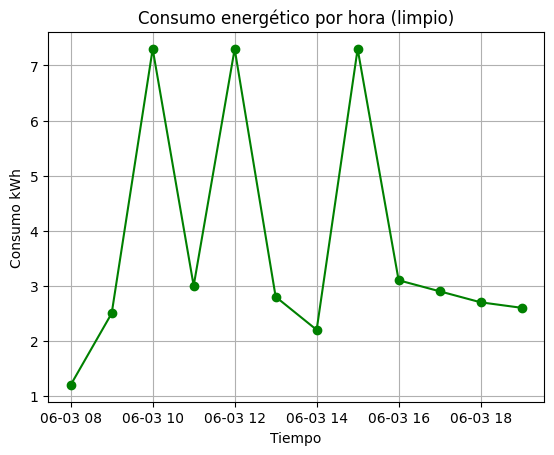

In [ ]:
# ---------------------------------------
# VISUALIZACIÓN
# ---------------------------------------
# Paso 6: Gráfico del consumo energético limpio
plt.plot(df["Tiempo"], df["Consumo_kWh"], marker='o', color='green')
plt.title("Consumo energético por hora (limpio)")
plt.xlabel("Tiempo")
plt.ylabel("Consumo kWh")
plt.grid(True)
plt.show()

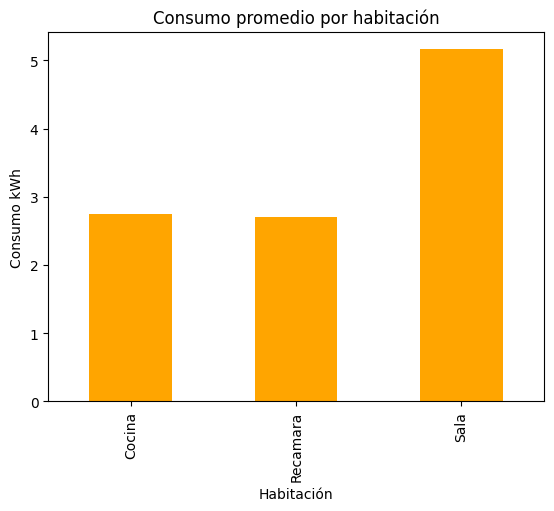

In [ ]:
# Paso 7: Gráfico comparativo por habitación
df.groupby("Habitacion")["Consumo_kWh"].mean().plot(kind="bar", color="orange")
plt.title("Consumo promedio por habitación")
plt.xlabel("Habitación")
plt.ylabel("Consumo kWh")
plt.show()

In [ ]:
# ---------------------------------------
# OPTIMIZACIÓN Y ALERTAS
# ---------------------------------------
# Paso 8: Definir regla de alerta preventiva
# Si el consumo normalizado > 0.8 → emitir alerta
df["Alerta"] = df["Consumo_Normalizado"] > 0.8
print("\nAlertas detectadas:")
print(df[["Tiempo","Habitacion","Consumo_kWh","Alerta"]])
print(df)


Alertas detectadas:
                Tiempo Habitacion  Consumo_kWh  Alerta
0  2026-06-03 08:00:00       Sala          1.2   False
1  2026-06-03 09:00:00     Cocina          2.5    True
2  2026-06-03 10:00:00       Sala          7.3    True
3  2026-06-03 11:00:00   Recamara          3.0    True
4  2026-06-03 12:00:00       Sala          7.3    True
5  2026-06-03 13:00:00     Cocina          2.8    True
6  2026-06-03 14:00:00   Recamara          2.2    True
7  2026-06-03 15:00:00       Sala          7.3    True
8  2026-06-03 16:00:00     Cocina          3.1    True
9  2026-06-03 17:00:00   Recamara          2.9    True
10 2026-06-03 18:00:00       Sala          2.7    True
11 2026-06-03 19:00:00     Cocina          2.6    True
                Tiempo  Consumo_kWh  Temperatura Habitacion  \
0  2026-06-03 08:00:00          1.2         22.0       Sala   
1  2026-06-03 09:00:00          2.5         23.0     Cocina   
2  2026-06-03 10:00:00          7.3         22.0       Sala   
3  2026-06-0